# ***Hydrologi*** - Skalering, tilsig og  middelvannføring 

Her ligger kode til beregninger og plott av hydrologiske data knyttet til Grøddalen.

In [28]:
# import av nødvendige Python bibliotek

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import matplotlib.dates as mdates
import datetime as dt

### *Skalering av tilsig/vannføring i Grøddalen*

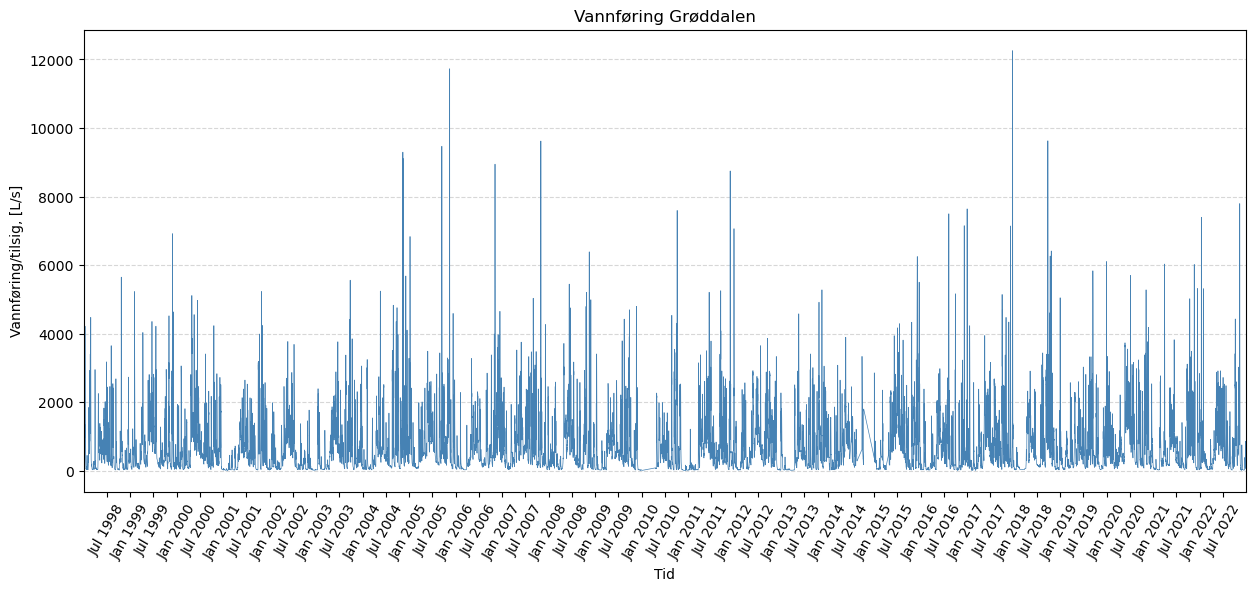

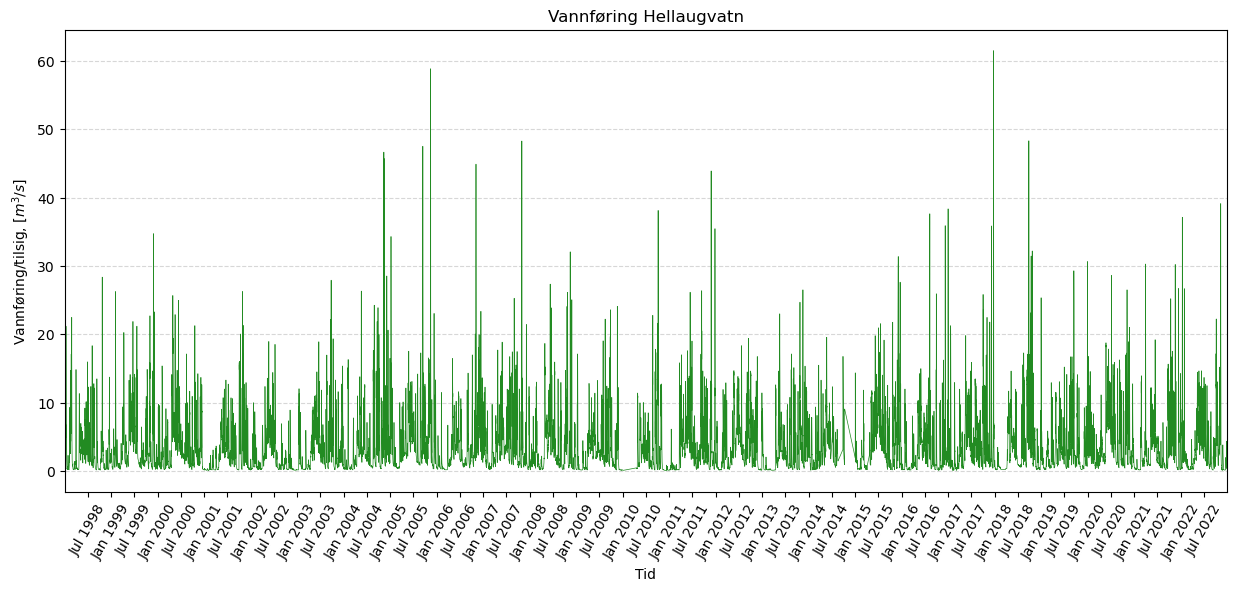

In [29]:
# Lese Excel-fil 
data = pd.read_csv("41.8_Hellaugvatn_1.csv", delimiter = ";", decimal = ",", header = 1) 

#Henter data fra kolonne 3 
Q = data.iloc[1:218999, 2].to_numpy()         #Vannføring per time fra målestasjon Hellaugvatn m^3/s
Q_m = Q * 1000                                #Omgjøring av enhet, vannføring Hellaugvatn [L/s]

#Kombinerer dato og tid til én datetime-kolonne
t_vec = pd.to_datetime(data.iloc[1:218999, 0] + "" + data.iloc[1:218999,1], format ="%d.%m.%Y%H:%M" ).to_numpy()


#Definerer Feltareal, Årlig middelavrenning og skaleringsfaktor
Areal_H = 27.49     # Feltareal Hellaugvatn [km^2], Verdi henta fra Sildre
Areal_G = 4.8       # Feltaral Grøddalen [km^2] 

F_H = (np.mean(Q_m))/Areal_H        #Årlig middelavrenning Hellaugvatn [L/s*km^2], Beregnet fra verdier fra målestasjonen

F_G = 139.8                        #Årlig middelavrenning Grøddalen [L/s*km^2], Verdi fra NEVINA 1961-1990
Skalering_f = (F_G * Areal_G) / (F_H * Areal_H)  #Skaleringsfaktor 

#Beregnet tilsig/vannføring i Grøddalen
Q_G = Q_m * Skalering_f  #[L/s]

#Lager plott som viser vannføring/tilsig til Grøddalen og Hellaugvatn
plt.figure(figsize=(15, 6))
plt.plot(t_vec,Q_G, color = "steelblue", linewidth=0.5)
plt.xlabel("Tid")
plt.ylabel("Vannføring/tilsig, [L/s]")
plt.title("Vannføring Grøddalen")
plt.xticks(rotation=60)
plt.xlim(t_vec[1], t_vec[-1])
plt.gca().xaxis.set_major_locator(mdates.MonthLocator(bymonth=[1, 7]))  # Viser én dato per måned i Januar og Juli
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))  # Format: "Jan 2020", "Feb 2020"
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.show()

plt.figure(figsize=(15, 6))
plt.plot(t_vec,Q, color = "forestgreen", linewidth=0.5)
plt.xlabel("Tid")
plt.ylabel("Vannføring/tilsig, $[m^3/s]$")
plt.title("Vannføring Hellaugvatn")
plt.xticks(rotation=60)
plt.xlim(t_vec[1], t_vec[-1])
plt.gca().xaxis.set_major_locator(mdates.MonthLocator(bymonth=[1, 7]))  # Viser én dato per måned i Januar og Juli
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))  # Format: "Jan 2020", "Feb 2020"
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.show()

In [3]:
# Nøkkel-parametre:

print(f'Årlig middelavrenning Hellaugvatn, beregnet av tilsigsdata fra målestasjonen:{np.round(F_H,1)} [L/s*km^2]')
print(f'Skaleringsfaktor: {np.round(Skalering_f,4)}')
#print(Q_G)
#print(F_H)


Årlig middelavrenning Hellaugvatn, beregnet av tilsigsdata fra målestasjonen:122.5 [L/s*km^2]
Skaleringsfaktor: 0.1993


In [4]:
# Deler opp data i tilhørende år
years = pd.DatetimeIndex(t_vec).year

Q_per_aar = {
    year: Q_G[years == year]
    for year in np.unique(years)} # Brukes til å hente alle verdier for vannføring for bestemt år

tid_per_aar = {
    year: t_vec[years == year]
    for year in np.unique(years)} # Brukes til å hente datoer og tid for målingene for bestemt år


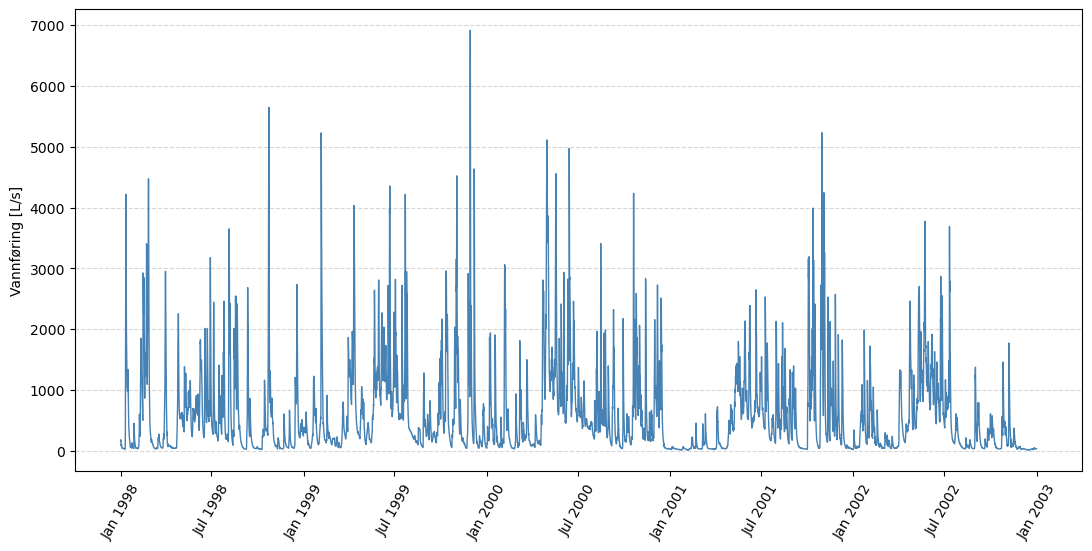

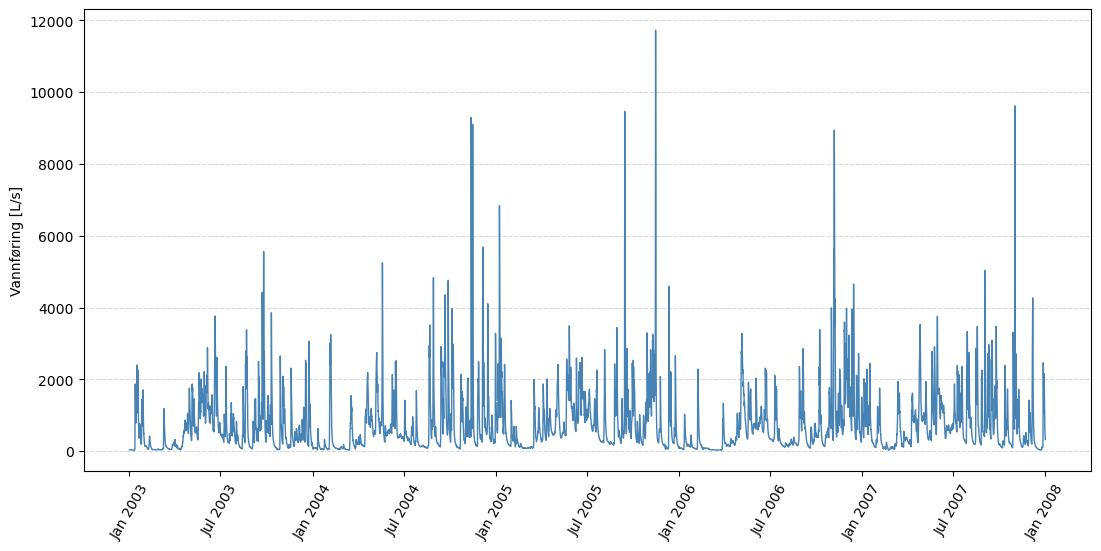

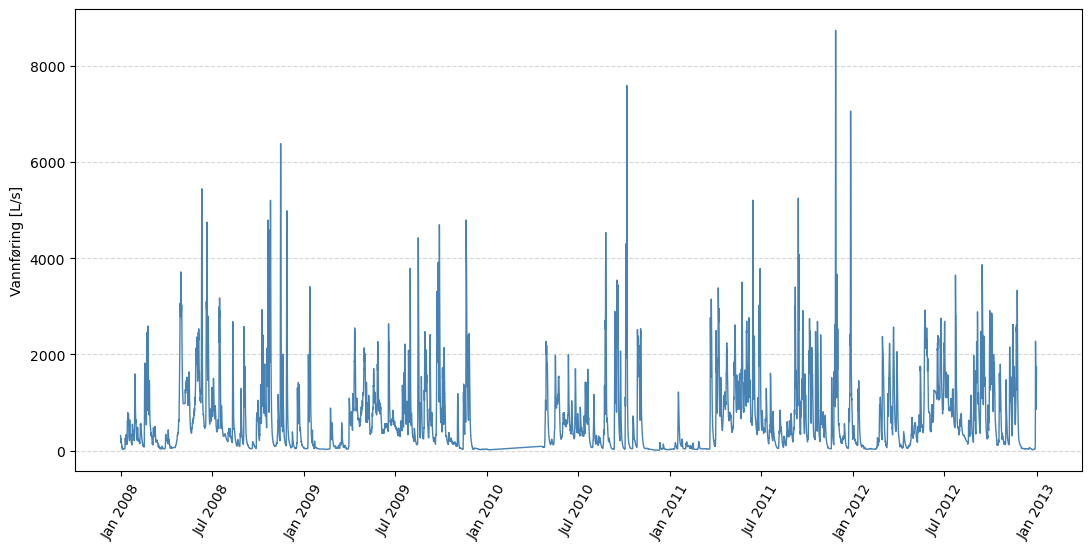

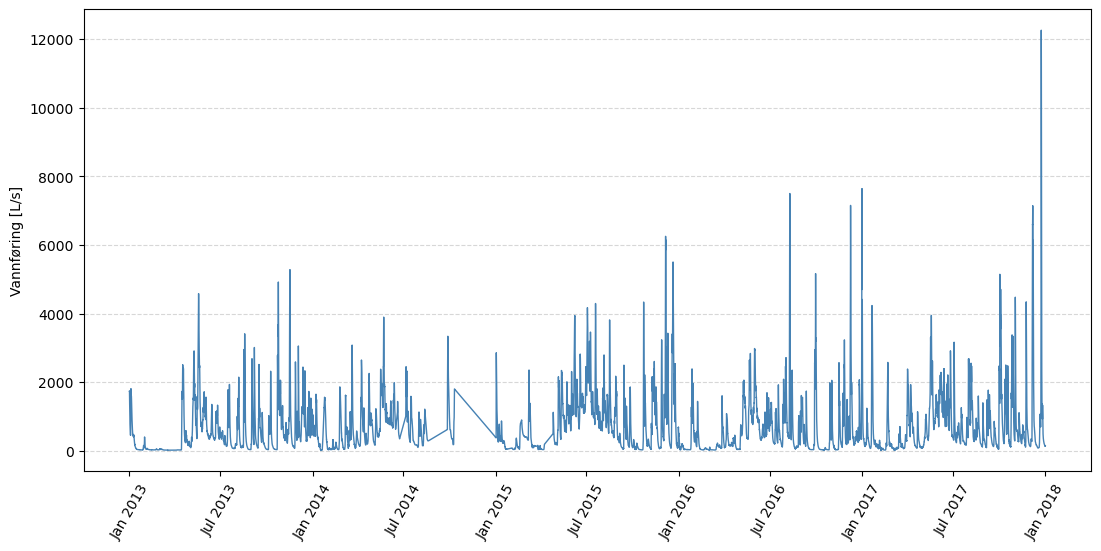

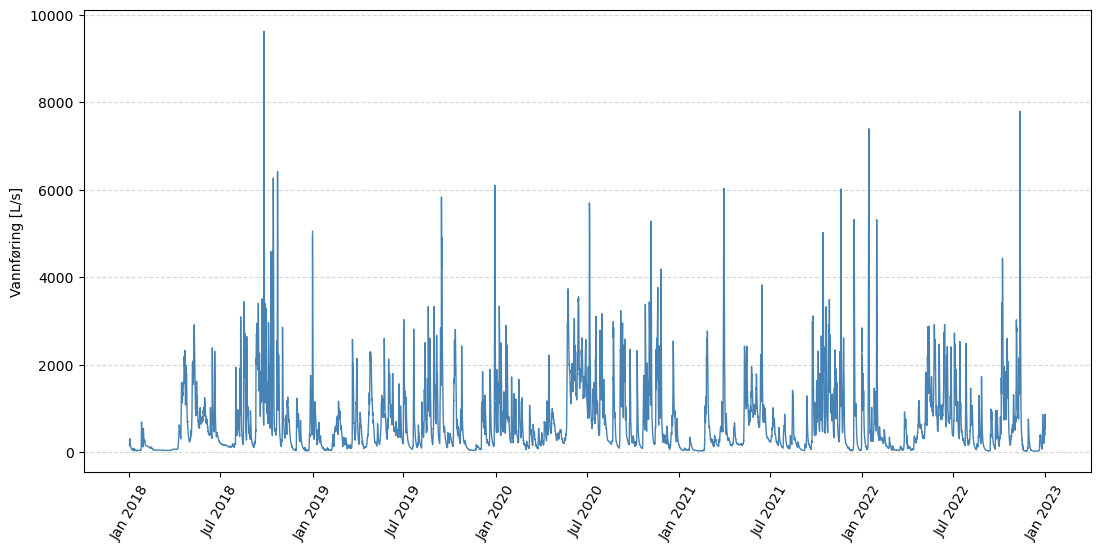

In [27]:
# For at plottet for estimert tilsig skal bli lettere å lese, deles den inn i 5 års-intervall

alle_aar = sorted(Q_per_aar.keys())

for i in range(0, len(alle_aar), 5):
    blokk = alle_aar[i:i+5]

    plt.figure(figsize=(13, 6))
    for year in blokk:
        plt.plot(tid_per_aar[year], Q_per_aar[year], linewidth=1, color = "steelblue")

    plt.ylabel("Vannføring [L/s]")
    plt.gca().xaxis.set_major_locator(mdates.MonthLocator(bymonth=[1, 7]))  # Viser én dato per måned i Januar og Juli
    plt.gca().xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))  # Format: "Jan 2020", "Feb 2020"
    plt.xticks(rotation=60)
    plt.grid(axis="y", linestyle="--", alpha=0.5)
    plt.show()

### *Middelvannføring*

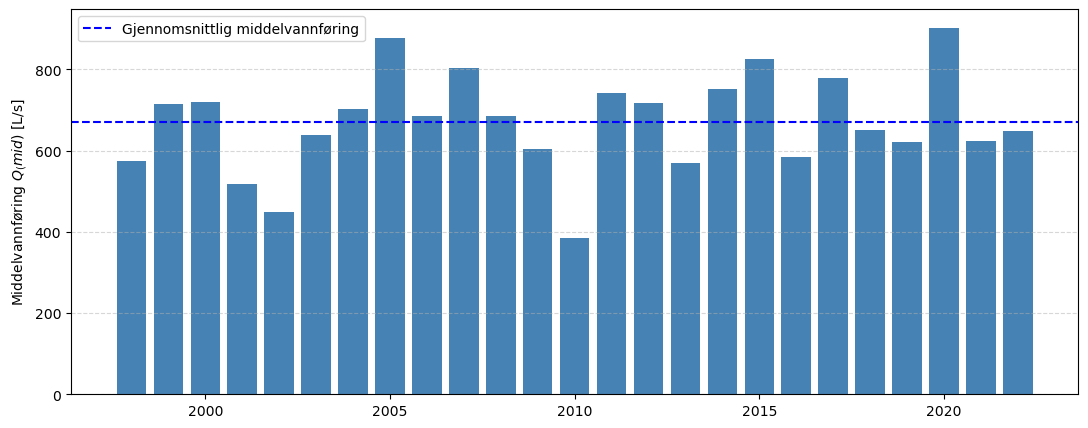

In [22]:
#Beregner middelvannføring for hvert år
middel_Q_per_aar = {
    year: np.mean(Q_G[years == year])
    for year in np.unique(years)} 

År = list(middel_Q_per_aar.keys())
middelverdier = list(middel_Q_per_aar.values()) #Legger inn som lister

#Beregner gjennomsnittlig middelvannføring
Q_mid = np.mean(Q_G) # Grøddalen [L/s]


#Plotter figur med middelverdier for hvert år og gjennomsnittlig middelverdi
plt.figure(figsize=(13,5))
plt.bar(År, middelverdier, color = "steelblue")
#plt.xlabel("År")
plt.ylabel("Middelvannføring $Q_(mid)$ [L/s]")
#plt.title("Årlig middelvannføring – Grøddalen")
plt.axhline(y = Q_mid, color = "blue", linestyle = "--", label = "Gjennomsnittlig middelvannføring")
plt.legend()
plt.grid(axis="y", linestyle = "--", alpha = 0.5)
plt.show()

In [23]:
# Nøkkel-parametre

print(f'Gjennomsnittlig middelvannføring i Grøddalen: {np.round(Q_mid,2)} [L/s]')
print("")
print(f'Middelvannføring året 2006: {np.round(middel_Q_per_aar[2006],2)} [L/s]')
print(f'Middelvannføring året 2010: {np.round(middel_Q_per_aar[2010],2)} [L/s]')
print(f'Middelvannføring året 2020: {np.round(middel_Q_per_aar[2020],2)} [L/s]')


Gjennomsnittlig middelvannføring i Grøddalen: 671.04 [L/s]

Middelvannføring året 2006: 685.14 [L/s]
Middelvannføring året 2010: 383.77 [L/s]
Middelvannføring året 2020: 902.87 [L/s]


### *Normalt, vått og tørt år*

***Normaltilsig*** er et statistisk gjennomsnitt over en referanseperiode (ofte 30 år eks. 1991 - 2020). Tilsig er definert som den totale mengden vann som renner inn i et nedbørfelt i løpet av et år. Når man ser på tilsigsdata for en tidsserie, kan det være nyttig å kategorisere serien basert på årlig middelvannføring. 

- *Normalt år*:  årstilsiget ligger nær langtidsmiddelet
- *Tørt år*: årstilsiget ligger betydelig under normalen.
- *Vått år*: årstilsiget ligger betydelig over normalen. 

Ut fra gjennomsnittlig middelvannføring *Q*<sub>mid</sub> og plottet over årlig middelvannføring i Grøddalen, leses hvilke/hvilket år år som er vått, tørt og normalt år. 
- Normalt år : **2006** 
- Tørt år: **2010**
- Vått år: **2020**

Normalår som kan benyttes: 1991 - 2000 - 2003 - 2004 - 2006 - 2008 - 2012 - 2018 - 2022

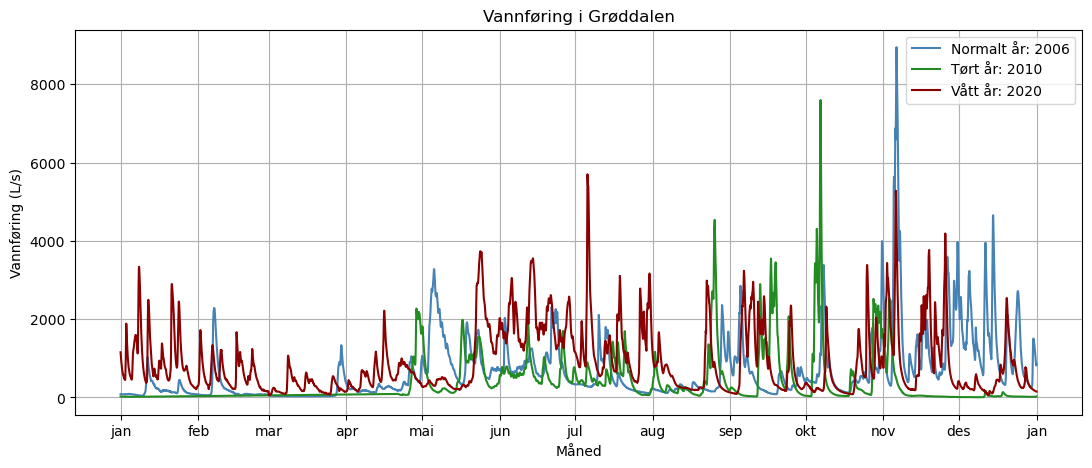

In [24]:
#Vannføring for vått, tørt og normalt år

#Definerer de ulike årene
normalt_år = 2006
tørt_år = 2010
vått_år = 2020

# Funksjon som lager datoer for et gitt år
def lag_datoer(år, n_timestep):
    start = dt.datetime(år, 1, 1)
    return [start + dt.timedelta(hours=i) for i in range(n_timestep)]

# Lager dato-akse
dato = lag_datoer(normalt_år, len(Q_per_aar[normalt_år]))

måneder = ["jan", "feb", "mar", "apr", "mai", "jun", "jul", "aug", "sep", "okt", "nov", "des"]


class NorskFormatter(mdates.DateFormatter):
    def __call__(self, x, pos=0):
        dt_obj = mdates.num2date(x)
        return måneder[dt_obj.month - 1]


#Plotter i samme figur
plt.figure(figsize=(13,5))
plt.plot(dato, Q_per_aar[normalt_år], color = "steelblue", label = "Normalt år: 2006")
plt.plot(dato, Q_per_aar[tørt_år], color = "forestgreen", label = "Tørt år: 2010")
plt.plot(dato, Q_per_aar[vått_år], color = "darkred", label = "Vått år: 2020")

# Formatering av x-aksen
ax = plt.gca()
ax.xaxis.set_major_locator(mdates.MonthLocator())
ax.xaxis.set_major_formatter(NorskFormatter("%b"))

plt.xlabel("Måned")
plt.ylabel("Vannføring (L/s)")
plt.title("Vannføring i Grøddalen")
plt.legend()
plt.grid()
plt.show()



##### **Setter sammen flere normalår til ett gjennomsnittlig normlår**

- Normalår: 1991 - 2000 - 2003 - 2004 - 2006 - 2008 - 2012 - 2018 - 2022


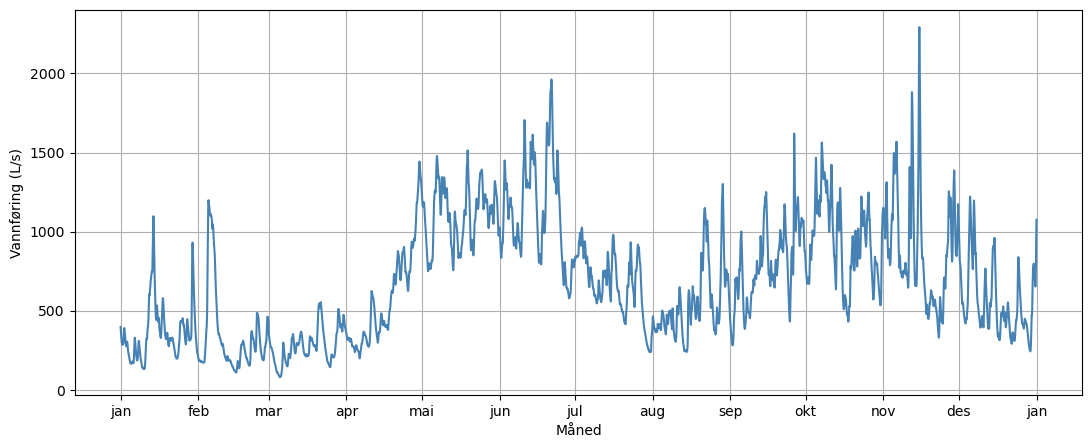

In [26]:
normalår = [Q_per_aar[1999], Q_per_aar[2000], Q_per_aar[2003], Q_per_aar[2004], Q_per_aar[2006], Q_per_aar[2008], Q_per_aar[2012],
           Q_per_aar[2018], Q_per_aar[2022]]

konverter = np.vstack(normalår)

Q_snitt_normalår = konverter.mean(axis=0)

#Plotter i samme figur
plt.figure(figsize=(13,5))
plt.plot(dato, Q_snitt_normalår, color = "steelblue")

# Formatering av x-aksen
ax = plt.gca()
ax.xaxis.set_major_locator(mdates.MonthLocator())
ax.xaxis.set_major_formatter(NorskFormatter("%b"))

plt.xlabel("Måned")
plt.ylabel("Vannføring (L/s)")
#plt.title("Vannføring gjennomsnittlig normalår i Grøddalen")
#plt.legend()
plt.grid()
plt.show()

## *Varighetskurve*
En varighetskurve viser hvor stor andel av tiden vannføringen er større eller mindre enn en viss verdi. Alle vannføringene i tidsserien er sortert fra høyest til lavest verdi. Ofte plottes varighetskurver med relative vannføringer på y-aksen, det vil si vannføring i prosent av middelavløpet. [Flow Duration Curves](https://vt-hydroinformatics.github.io/fdcs.html)


Varighetskurven lages med tre enkle steg:
 1. Samle data med vannføring for en lengre periode
  2. Sorter data for alle vannføringsverdiene (m^3/s) i synkende rekkefølge, fra høyest til lavest verdi.
  3. Beregn hvor mange % av tiden hver vannføring overskrides

- **Formel:** Varighet (%) = m / (n + 1) *100%

 Hvor *m* = rangert posisjon til strømningen og *n* = totalt antall observasjoner i datasettet. 

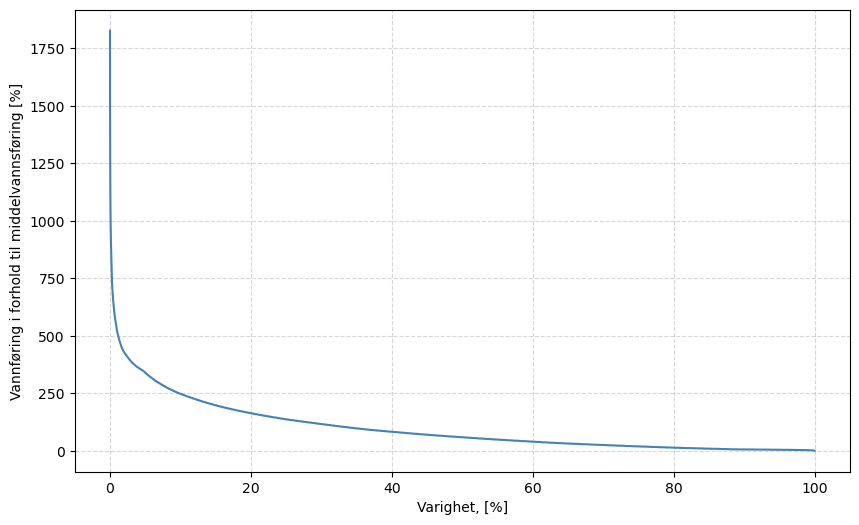

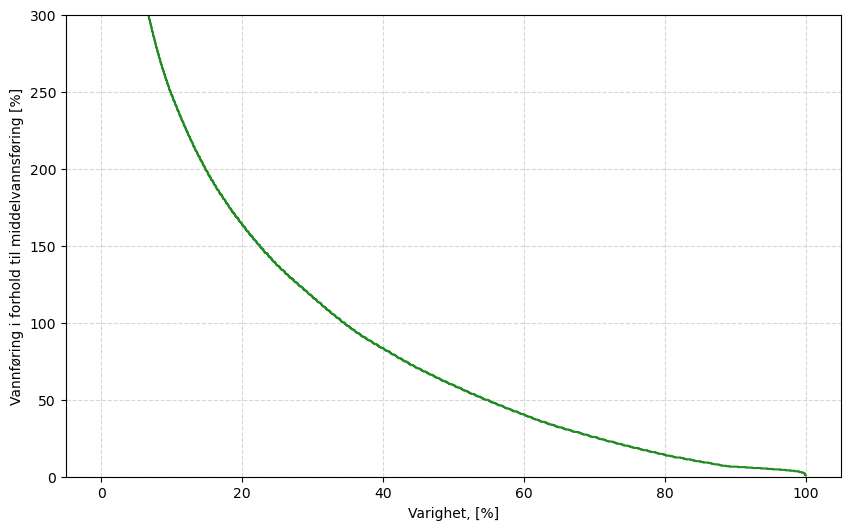

In [30]:
#Varighetskurve
Q_sortert = np.sort(Q_G)[::-1]  # Sorterer verdiene i synkende rekkefølge

n = len(Q_sortert)
m = np.arange(1, n+1)

Varighet = m / (n +1) 

Relativ_Q = (Q_sortert / Q_mid ) * 100 #Konverterer vannføringen i prosent av middelvannføring

# Plotter varighetskurven med x- og y-akse i prosent
plt.figure(figsize=(10, 6))
plt.plot(Varighet*100, Relativ_Q, color = "steelblue") #Varihet * 100 %
plt.xlabel("Varighet, [%]")
plt.ylabel("Vannføring i forhold til middelvannsføring [%]")
#plt.title("Varighetskurve for Grøddalen")
plt.grid(linestyle="--", alpha=0.5)
plt.show()


#For å gjøre grafen lettere å lese er figuren ”kuttet” for vannføringer større enn 3 ganger middelavløpet
# Plotter varighetskurven med x- og y-akse i prosent
plt.figure(figsize=(10, 6))
plt.plot(Varighet*100, Relativ_Q, color = "forestgreen") #Varihet * 100 %
plt.ylim(0, 300)
plt.xlabel("Varighet, [%]")
plt.ylabel("Vannføring i forhold til middelvannsføring [%]")
#plt.title("Varighetskurve for Grøddalen")
plt.grid(linestyle="--", alpha=0.5)
plt.show()

### *Minstevannføring*

#### *Ved bruk av 5-percentil*

Q95-metoden baserer seg på vannføringsdata fra tidsserier, der minstevannføringskravet settes etter Q95-verdien, som er verdien som overskrides 95% av tiden. Dette er for å sikre at vannføringen ikke blir lavere enn fem prosent av historiske data for vannføringen i elva. 

#### Sesongvariasjoner i et normalår

Det kan forekomme variasjoner for minstevannsføringskrav gjennom året, av hensyn til sesongvariasjoner for den naturlige vannføringen. Dermed skilles det ofte mellom 5-persentil for sommer (f.eks. 1. mai – 30. sept) og vinter (1. okt – 30. april), hvor 5-persentil vinter ofte er lavere eller null.

In [31]:
#For hele tidsserien:
#Deler inn i sommer- (1/4-30/9) og vintersesong (1/10 - 31/3) for hele tidsserien
måneder = t_vec.astype("datetime64[M]").astype(int) % 12 +1

sommer = (måneder > 4) & (måneder < 10)
vinter = ~sommer

Q_sommer = Q_G[sommer]
Q_vinter = Q_G[vinter]

Q95_sommer = np.percentile(Q_sommer, 5)
Q95_vinter = np.percentile(Q_vinter, 5)

#For et normalår
Normalår = Q_per_aar[2006]            #Definerer hvilket år som skal brukes som normalår
Tid_normalår = tid_per_aar[2006]      #Definerer tidsakse

#Deler inn i sommer- (1/5-30/9) og vintersesong (1/10 - 31/3) for normalåret
måneder_normalår = Tid_normalår.astype("datetime64[M]").astype(int) % 12 +1

sommer_normalår = (måneder_normalår > 4) & (måneder_normalår < 10)
vinter_normalår = ~sommer_normalår

Q_sommer_normalår = Normalår[sommer_normalår]
Q_vinter_normalår = Normalår[vinter_normalår]

Q95_sommer_n = np.percentile(Q_sommer_normalår, 5)
Q95_vinter_n = np.percentile(Q_vinter_normalår, 5)


In [32]:
#Nøkkelparametre

#Sesongvariasjon hele tidsserien
print(f"Minstevannføring sommer, Q95-verdi, for hele tidsserien: {np.round(Q95_sommer,2)} [L/s]")
print(f"Minstevannføring vinter, Q95-verdi, for hele tidsserien: {np.round(Q95_vinter,2)} [L/s]")

print("")
#Sesongvariasjon et normalår
print(f"Minstevannføring sommer, Q95-verdi, for et normalår (2006): {np.round(Q95_sommer_n,2)} [L/s]")
print(f"Minstevannføring vinter, Q95-verdi, for et normalår (2006): {np.round(Q95_vinter_n,2)} [L/s]")


Minstevannføring sommer, Q95-verdi, for hele tidsserien: 91.67 [L/s]
Minstevannføring vinter, Q95-verdi, for hele tidsserien: 29.89 [L/s]

Minstevannføring sommer, Q95-verdi, for et normalår (2006): 125.55 [L/s]
Minstevannføring vinter, Q95-verdi, for et normalår (2006): 31.89 [L/s]


##### *Varighetskurve normalår*

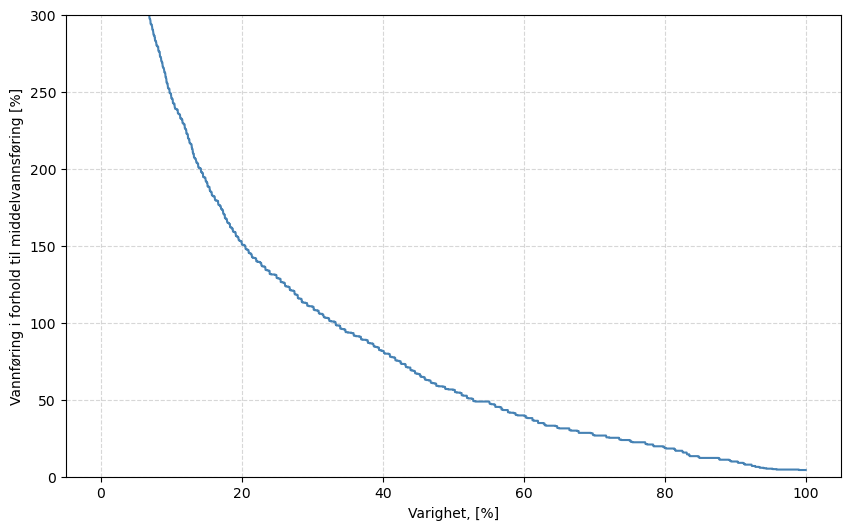

In [34]:
#Varighetskurve Normålår
Q_norm = np.sort(Q_per_aar[2006])[::-1]  # Sorterer verdiene i synkende rekkefølge

n = len(Q_norm)
m = np.arange(1, n+1)

Varighet_norm = m / (n +1) 

Relativ_Q_norm = (Q_norm / np.mean(Q_per_aar[2008]) ) * 100 #Konverterer vannføringen i prosent av middelvannføring

# Plotter varighetskurven med x- og y-akse i prosent
plt.figure(figsize=(10, 6))
plt.plot(Varighet_norm*100, Relativ_Q_norm, color = "steelblue") #Varihet * 100 %
plt.xlabel("Varighet, [%]")
plt.ylabel("Vannføring i forhold til middelvannsføring [%]")
#plt.title("Varighetskurve normalår")
plt.ylim(0, 300)
plt.grid(linestyle="--", alpha=0.5)
plt.show()